# Aug Ablation — Smart Factory NEU-DET

> **목표**: MobileNetV4-Conv-Small 모델 고정, 5가지 augmentation 변형의 (Macro F1, Inference Time) 영향 정량화.
>
> **References**: `wiki/method-aug-stack-2026-05-06.md`, `output/insights/aug-ablation-plan-20260506.md`
>
> **Reproducibility**: seed 42 고정, deterministic algorithms.

⚠️ **2026-05-06 룰 갱신 반영**:
- Final Score = `max(0, MacroF1×100 − max(0, (T_inf − 1) × 2.5))`
- 무감점 budget = 1초, 실격 = 30초
- 1s/180 = **5.5 ms/img** anchor (매우 타이트)
- fp32 MobileNetV4-Conv-Small CPU에서 latency budget(1s) 못 들어감 — 이 ablation은 **aug 효과 측정 전용**, latency 압축은 별도 INT8 round에서.

## 7 Variants
1. **V1 Vanilla** — Resize + Normalize 만 (baseline)
2. **V2 + TrivialAugment** — V1 + TrivialAugmentWide + HFlip
3. **V3 + Vertical MotionBlur** — V1 + 수직 motion blur (k=[3,31])
4. **V4 + AugMix + JS** — torchvision AugMix + JS divergence loss (λ=12)
5. **V5 Combined** — V2 + V3 + V4
6. **V6 + Manifold Mixup (L4)** — V5 + Manifold Mixup at penultimate features (inter-class only, λ~Beta(2,2))
7. **V7 + SynerMix (L4 best)** — V6 + Intra-class mixup (same-class pair, λ_intra=0.3)

각 variant: 30 epoch 학습 → val/dummy 평가 → 180 real test CPU 추론·latency 측정 → submission CSV 저장.
결과 표는 마지막 cell에서 출력.

---

## 실행 노트
- GPU 권장 (학습 속도). 추론 latency는 강제 CPU.
- 미설치 시: `pip install -q timm torch torchvision scikit-learn pillow numpy opencv-python pandas tabulate`
- BASE 경로 본인 환경에 맞게 수정 (Cell 3)


In [20]:
# Colab 또는 새 환경에서 실행 시 아래 라인 활성화 (통합 환경 — implementation/requirements.txt)
# %pip install -q -r ../../requirements.txt

# === Setup ===
import os, sys, time, random, copy, json
from dataclasses import dataclass, field
from typing import List

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
from torchvision.datasets import ImageFolder
from PIL import Image
import cv2
from sklearn.metrics import f1_score, confusion_matrix
import matplotlib.pyplot as plt
import pandas as pd
import timm

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
try:
    torch.use_deterministic_algorithms(True, warn_only=True)
except Exception as e:
    print(f'deterministic warn: {e}')

if torch.cuda.is_available():
    DEVICE = 'cuda'
elif torch.backends.mps.is_available():
    DEVICE = 'mps'
    torch.mps.manual_seed(SEED)
else:
    DEVICE = 'cpu'
print('Python:', sys.version.split()[0])
print('PyTorch:', torch.__version__, '| timm:', timm.__version__)
print('CUDA:', torch.cuda.is_available(), '| MPS:', torch.backends.mps.is_available(), '| Train device:', DEVICE)
print('(Inference latency 측정은 강제 CPU)')

Python: 3.12.12
PyTorch: 2.11.0 | timm: 1.0.15
CUDA: False | MPS: True | Train device: mps
(Inference latency 측정은 강제 CPU)


In [ ]:
# === Config & Paths ===
@dataclass
class Config:
    BASE: str = '/Users/sangyub/Downloads/Smart-Factory_AI_Challenge/smart-factory_obisian/raw/competition/2026-1-machine-learning-in-prace'
    OUT_DIR: str = '/Users/sangyub/Downloads/Smart-Factory_AI_Challenge/smart-factory_obisian/implementation/experiments/aug-ablation-2026-05-06'
    MODEL_NAME: str = 'mobilenetv4_conv_small.e2400_r224_in1k'
    PRETRAINED: bool = True
    EPOCHS: int = 30
    BATCH_SIZE: int = 32
    LR: float = 1e-3
    WEIGHT_DECAY: float = 0.01
    NUM_WORKERS: int = 0  # macOS spawn + Jupyter: TrainDataset이 __main__에 정의되어 worker pickle 불가 → 0으로 강제
    INPUT_SIZE: int = 224
    AUGMIX_LAMBDA: float = 12.0
    EARLY_STOP_PATIENCE: int = 20  # val_f1 갱신 X 가 N epoch 연속이면 break (0 또는 큰 값으로 비활성)
    VARIANTS: List[str] = field(default_factory=lambda: [
        'V1_vanilla', 'V2_trivialaug', 'V3_vmotionblur', 'V4_augmix', 'V5_combined', 'V6_manifold_mixup', 'V7_synermix'
    ])


cfg = Config()
os.makedirs(cfg.OUT_DIR, exist_ok=True)

# === Accumulation paths (덮어쓰기 방지 — 매 run 누적) ===
from datetime import datetime
RUN_ID = datetime.now().strftime('%Y%m%d_%H%M%S')
RUNS_DIR = os.path.join(cfg.OUT_DIR, 'runs')
LEADERBOARD_PATH = os.path.join(cfg.OUT_DIR, 'leaderboard.json')
os.makedirs(RUNS_DIR, exist_ok=True)
for _v in cfg.VARIANTS:
    os.makedirs(os.path.join(RUNS_DIR, _v), exist_ok=True)
print(f'🆔 RUN_ID = {RUN_ID}')
print(f'📂 runs/ = {RUNS_DIR}')
print(f'📊 leaderboard = {LEADERBOARD_PATH}')

# === Model alias (파일명 prefix용) ===
def model_alias(name: str) -> str:
    """timm model name → 짧은 alias for filename. unknown 모델은 단순 fallback."""
    short = {
        'mobilenetv4_conv_small': 'mbv4cs',
        'mobilenetv4_conv_medium': 'mbv4cm',
        'mobilenetv4_conv_large': 'mbv4cl',
        'mobilenetv4_hybrid_medium': 'mbv4hm',
        'mobilenetv4_hybrid_large': 'mbv4hl',
        'mobilenetv3_small_100': 'mbv3s',
        'mobilenetv3_small_075': 'mbv3s075',
        'mobilenetv3_large_100': 'mbv3l',
        'mobilenetv2_100': 'mbv2',
        'efficientnet_b0': 'effb0',
        'efficientnet_b1': 'effb1',
        'efficientnet_b2': 'effb2',
        'resnet18': 'r18',
        'resnet50': 'r50',
    }
    base = name.split('.')[0]   # pretrained tag (.e2400_r224_in1k 등) 제거
    if base in short:
        return short[base]
    return base.replace('_', '').replace('-', '')[:10]

MODEL_ALIAS = model_alias(cfg.MODEL_NAME)
print(f'🏷️  MODEL_ALIAS = {MODEL_ALIAS}  (from cfg.MODEL_NAME = {cfg.MODEL_NAME})')

TRAIN_DIR = f'{cfg.BASE}/competition_dataset/NEU-DET_open/train/images'
VAL_DIR   = f'{cfg.BASE}/competition_dataset/NEU-DET_open/validation/images'
DUMMY_DIR = f'{cfg.BASE}/competition_dataset/NEU-DET_open/test/images'
REAL_DIR  = f'{cfg.BASE}/test/test/images'

print('Path check:')
for n, p in [('train', TRAIN_DIR), ('val', VAL_DIR), ('dummy', DUMMY_DIR), ('real', REAL_DIR)]:
    print(f'  {n}: {os.path.isdir(p)} ({p})')

CLASSES = sorted([d for d in os.listdir(TRAIN_DIR) if not d.startswith('.')])
NUM_CLASSES = len(CLASSES)
IDX_TO_CLASS = {i: c for i, c in enumerate(CLASSES)}
print(f'\nClasses ({NUM_CLASSES}): {CLASSES}')
print(f'Output dir: {cfg.OUT_DIR}')


🆔 RUN_ID = 20260507_154937
📂 runs/ = /Users/sangyub/Downloads/Smart-Factory_AI_Challenge/smart-factory_obisian/implementation/experiments/aug-ablation-2026-05-06/runs
📊 leaderboard = /Users/sangyub/Downloads/Smart-Factory_AI_Challenge/smart-factory_obisian/implementation/experiments/aug-ablation-2026-05-06/leaderboard.json
🏷️  MODEL_ALIAS = mbv4cs  (from cfg.MODEL_NAME = mobilenetv4_conv_small.e2400_r224_in1k)
Path check:
  train: True (/Users/sangyub/Downloads/Smart-Factory_AI_Challenge/smart-factory_obisian/raw/competition/2026-1-machine-learning-in-prace/competition_dataset/NEU-DET_open/train/images)
  val: True (/Users/sangyub/Downloads/Smart-Factory_AI_Challenge/smart-factory_obisian/raw/competition/2026-1-machine-learning-in-prace/competition_dataset/NEU-DET_open/validation/images)
  dummy: True (/Users/sangyub/Downloads/Smart-Factory_AI_Challenge/smart-factory_obisian/raw/competition/2026-1-machine-learning-in-prace/competition_dataset/NEU-DET_open/test/images)
  real: True (/Us

In [22]:
# === Vertical Motion Blur (custom transform) ===
# Reference: paper-ccmba-2023, finding-vertical-motion-blur, finding-test-blur-bimodal
class VerticalMotionBlur:
    """Linear motion blur, angle ~ 90° ± 5°, kernel size random in [k_min, k_max]."""
    def __init__(self, p=0.7, k_min=3, k_max=31):
        self.p, self.k_min, self.k_max = p, k_min, k_max

    def __call__(self, img_pil):
        if np.random.rand() > self.p:
            return img_pil
        k = int(np.random.choice(range(self.k_min, self.k_max + 1, 2)))  # odd
        angle = 90.0 + float(np.random.uniform(-5, 5))
        kernel = np.zeros((k, k), dtype=np.float32)
        cv2.line(kernel, (k // 2, 0), (k // 2, k - 1), 1.0, thickness=1)
        M = cv2.getRotationMatrix2D((k / 2, k / 2), angle - 90, 1.0)
        kernel = cv2.warpAffine(kernel, M, (k, k))
        s = float(kernel.sum())
        kernel = kernel / max(s, 1e-6)
        arr = np.asarray(img_pil)
        out = cv2.filter2D(arr, -1, kernel)
        return Image.fromarray(out)

# Sanity check
_t = Image.fromarray(np.random.randint(0, 256, (200, 200, 3), dtype=np.uint8))
_o = VerticalMotionBlur(p=1.0)(_t)
print('VerticalMotionBlur OK:', _o.size, _o.mode)

VerticalMotionBlur OK: (200, 200) RGB


In [23]:
# === Transform pipelines per variant ===
NORMALIZE = T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
RESIZE = T.Resize((cfg.INPUT_SIZE, cfg.INPUT_SIZE))
TO_TENSOR_NORM = T.Compose([T.ToTensor(), NORMALIZE])
EVAL_TF = T.Compose([RESIZE, T.ToTensor(), NORMALIZE])

BASE_AUGS = {
    'V1_vanilla': T.Compose([RESIZE]),
    'V2_trivialaug': T.Compose([
        RESIZE,
        T.RandomHorizontalFlip(p=0.5),
        T.TrivialAugmentWide(),
    ]),
    'V3_vmotionblur': T.Compose([
        RESIZE,
        VerticalMotionBlur(p=0.7),
    ]),
    'V4_augmix': T.Compose([RESIZE]),
    'V5_combined': T.Compose([
        RESIZE,
        T.RandomHorizontalFlip(p=0.5),
        T.TrivialAugmentWide(),
        VerticalMotionBlur(p=0.7),
    ]),
    'V6_manifold_mixup': T.Compose([
        RESIZE,
        T.RandomHorizontalFlip(p=0.5),
        T.TrivialAugmentWide(),
        VerticalMotionBlur(p=0.7),
    ]),
    'V7_synermix': T.Compose([
        RESIZE,
        T.RandomHorizontalFlip(p=0.5),
        T.TrivialAugmentWide(),
        VerticalMotionBlur(p=0.7),
    ]),
}
USE_AUGMIX = {
    'V1_vanilla': False, 'V2_trivialaug': False, 'V3_vmotionblur': False,
    'V4_augmix': True,  'V5_combined': True,
    'V6_manifold_mixup': True, 'V7_synermix': True,
}

try:
    AUGMIX_TF = T.AugMix(severity=3, mixture_width=3, chain_depth=-1, alpha=1.0)
    print('torchvision AugMix OK')
except Exception as e:
    print(f'⚠️ AugMix not available: {e} — V4/V5 will fall back to identity')
    AUGMIX_TF = T.Compose([])

torchvision AugMix OK


In [24]:
# === Datasets ===
class TrainDataset(Dataset):
    def __init__(self, root, base_aug, use_augmix):
        self.imgs = ImageFolder(root)  # PIL → no transform
        self.base_aug = base_aug
        self.use_augmix = use_augmix
    def __len__(self):
        return len(self.imgs)
    def __getitem__(self, i):
        img, y = self.imgs[i]
        img_aug = self.base_aug(img)
        x = TO_TENSOR_NORM(img_aug)
        if self.use_augmix:
            x1 = TO_TENSOR_NORM(AUGMIX_TF(img_aug))
            x2 = TO_TENSOR_NORM(AUGMIX_TF(img_aug))
            return x, x1, x2, y
        return x, y

class RealTestDataset(Dataset):
    def __init__(self, root, transform):
        self.files = sorted([f for f in os.listdir(root) if f.endswith('.jpg')])
        self.root = root; self.transform = transform
    def __len__(self):
        return len(self.files)
    def __getitem__(self, i):
        fname = self.files[i]
        img = Image.open(os.path.join(self.root, fname)).convert('RGB')
        return self.transform(img), fname

def worker_init(worker_id):
    np.random.seed(SEED + worker_id)
    random.seed(SEED + worker_id)

val_loader = DataLoader(ImageFolder(VAL_DIR, transform=EVAL_TF),
                        batch_size=cfg.BATCH_SIZE, shuffle=False,
                        num_workers=cfg.NUM_WORKERS, worker_init_fn=worker_init)
dummy_loader = DataLoader(ImageFolder(DUMMY_DIR, transform=EVAL_TF),
                          batch_size=cfg.BATCH_SIZE, shuffle=False,
                          num_workers=cfg.NUM_WORKERS, worker_init_fn=worker_init)
real_loader = DataLoader(RealTestDataset(REAL_DIR, EVAL_TF),
                         batch_size=cfg.BATCH_SIZE, shuffle=False,
                         num_workers=cfg.NUM_WORKERS, worker_init_fn=worker_init)

print(f'Val: {len(val_loader.dataset)} | Dummy: {len(dummy_loader.dataset)} | Real test: {len(real_loader.dataset)}')

Val: 180 | Dummy: 12 | Real test: 180


In [25]:
# === Model + JS divergence + Train function ===
def make_model():
    return timm.create_model(cfg.MODEL_NAME, num_classes=NUM_CLASSES, pretrained=cfg.PRETRAINED)

def js_div(logits_list):
    """Jensen-Shannon divergence among list of logits (B, C). Returns scalar."""
    probs = [F.softmax(p, dim=-1) for p in logits_list]
    p_mean = sum(probs) / len(probs)
    p_mean = torch.clamp(p_mean, 1e-7, 1.0)
    js = 0.0
    for p in logits_list:
        js = js + F.kl_div(F.log_softmax(p, dim=-1), p_mean, reduction='batchmean')
    return js / len(logits_list)


@torch.no_grad()
def eval_with_details(model, loader, device=None):
    """Macro F1 + per-class F1 + confusion matrix 한 번에."""
    device = device or DEVICE
    model.eval()
    ys, ps = [], []
    for x, y in loader:
        x = x.to(device)
        out = model(x).argmax(-1).cpu().numpy()
        ys.append(y.numpy()); ps.append(out)
    y = np.concatenate(ys); p = np.concatenate(ps)
    macro = f1_score(y, p, average='macro')
    per_cls = f1_score(y, p, average=None, zero_division=0, labels=list(range(NUM_CLASSES)))
    cm = confusion_matrix(y, p, labels=list(range(NUM_CLASSES)))
    return macro, per_cls, cm

def compute_competition_score(macro_f1, t_inf_sec):
    """대회 공식 (2026-05-06 룰): Final = max(0, F1×100 - max(0, (T-1)×2.5)). T>30s 실격."""
    if t_inf_sec > 30.0:
        return 0.0, "실격 (T>30s)"
    penalty = max(0.0, (t_inf_sec - 1.0) * 2.5)
    score = max(0.0, macro_f1 * 100 - penalty)
    return score, f"penalty={penalty:.2f}"

@torch.no_grad()
def eval_macro_f1(model, loader):
    model.eval()
    ys, ps = [], []
    for x, y in loader:
        x = x.to(DEVICE)
        out = model(x).argmax(-1).cpu().numpy()
        ys.append(y.numpy()); ps.append(out)
    return f1_score(np.concatenate(ys), np.concatenate(ps), average='macro')

# === Leaderboard helpers (누적 기록) ===
def load_leaderboard():
    if not os.path.exists(LEADERBOARD_PATH):
        return {'runs': []}
    with open(LEADERBOARD_PATH) as f:
        return json.load(f)

def save_leaderboard(lb):
    with open(LEADERBOARD_PATH, 'w') as f:
        json.dump(lb, f, indent=2)

def get_variant_best_f1(variant_name, lb=None, alias=None):
    """그 variant + 같은 model_alias 의 leaderboard 누적 best val_f1 (없으면 -1).

    alias=None 이면 현재 cfg 의 MODEL_ALIAS 사용. 다른 model 은 별도 추적되도록.
    """
    lb = lb if lb is not None else load_leaderboard()
    a = alias if alias is not None else MODEL_ALIAS
    fs = [r['val_f1'] for r in lb['runs']
          if r['variant'] == variant_name and r.get('model_alias') == a]
    return max(fs) if fs else -1.0

def get_overall_best_run(by='score', lb=None, alias=None):
    """전체 best run 메타. by='score'(val proxy) | 'val_f1'.

    alias 지정 시 그 alias 의 run 만. None 이면 모든 run.
    """
    lb = lb if lb is not None else load_leaderboard()
    runs = lb['runs']
    if alias is not None:
        runs = [r for r in runs if r.get('model_alias') == alias]
    if not runs:
        return None
    key = (lambda r: r.get('score_val_proxy', -1)) if by == 'score' else (lambda r: r['val_f1'])
    return max(runs, key=key)

def append_leaderboard_run(entry):
    """entry append + persist. 반환: 갱신된 leaderboard dict."""
    lb = load_leaderboard()
    lb['runs'].append(entry)
    save_leaderboard(lb)
    return lb

# 매 train 끝나고 채워짐: variant -> {'run_pth': ..., 'run_hist': ..., 'best_val_f1': ..., 'best_epoch': ...}
_LAST_RUN_META = {}

def _save_run_artifacts(variant_name, model, history, best_val_f1, best_epoch, epochs_trained=None, extra_meta=None):
    """매 run 누적 저장 + variant best 갱신.

    파일명: {MODEL_ALIAS}__{variant}__{RUN_ID}__f1_{f1:.4f}.{pth,history.json}
    """
    ts = RUN_ID
    run_dir = os.path.join(RUNS_DIR, variant_name)
    os.makedirs(run_dir, exist_ok=True)
    fname_base = f'{MODEL_ALIAS}__{variant_name}__{ts}__f1_{best_val_f1:.4f}'
    run_pth = os.path.join(run_dir, f'{fname_base}.pth')
    run_hist = os.path.join(run_dir, f'{fname_base}.history.json')

    payload = {
        'variant': variant_name,
        'run_id': ts,
        'model_name': cfg.MODEL_NAME,
        'model_alias': MODEL_ALIAS,
        'state_dict': model.state_dict(),
        'history': history,
        'best_val_f1': best_val_f1,
        'best_epoch': best_epoch,
        'epochs_trained': epochs_trained if epochs_trained is not None else cfg.EPOCHS,
        'epochs_planned': cfg.EPOCHS,
        'config': {k: v for k, v in cfg.__dict__.items() if not k.startswith('_')},
    }
    if extra_meta:
        payload.update(extra_meta)

    # 누적 저장 (덮어쓰기 X)
    torch.save(payload, run_pth)
    with open(run_hist, 'w') as f:
        json.dump(history, f)
    print(f'  💾 [accum] runs/{variant_name}/{fname_base}.pth')

    # variant best 갱신 — 같은 model_alias 안에서 그 variant 최고일 때만
    prev_best = get_variant_best_f1(variant_name, alias=MODEL_ALIAS)
    variant_pth = os.path.join(cfg.OUT_DIR, f'model_{MODEL_ALIAS}__{variant_name}.pth')
    variant_hist = os.path.join(cfg.OUT_DIR, f'history_{MODEL_ALIAS}__{variant_name}.json')
    is_new_best = best_val_f1 > prev_best
    if is_new_best:
        torch.save(payload, variant_pth)
        with open(variant_hist, 'w') as f:
            json.dump(history, f)
        print(f'  ⭐ [variant best 갱신] prev={prev_best:.4f} → new={best_val_f1:.4f}  ({os.path.basename(variant_pth)})')
    else:
        print(f'  ⏭ [variant best 유지] prev={prev_best:.4f} ≥ new={best_val_f1:.4f}')

    _LAST_RUN_META[variant_name] = {
        'run_pth': run_pth,
        'run_hist': run_hist,
        'run_pth_rel': os.path.relpath(run_pth, cfg.OUT_DIR),
        'run_hist_rel': os.path.relpath(run_hist, cfg.OUT_DIR),
        'best_val_f1': best_val_f1,
        'best_epoch': best_epoch,
        'is_new_variant_best': is_new_best,
        'prev_variant_best': prev_best,
        'model_alias': MODEL_ALIAS,
    }
    return run_pth, run_hist


def train_variant(variant_name, train_ds):
    """학습 + best epoch 추적 + 누적 저장 (per run) + variant best 갱신."""
    torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
    use_augmix = USE_AUGMIX[variant_name]
    train_loader = DataLoader(train_ds, batch_size=cfg.BATCH_SIZE, shuffle=True,
                              num_workers=cfg.NUM_WORKERS, worker_init_fn=worker_init,
                              drop_last=True)
    model = make_model().to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=cfg.LR, weight_decay=cfg.WEIGHT_DECAY)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=cfg.EPOCHS)
    history = {'train_loss': [], 'val_f1': []}

    best_val_f1 = -1.0
    best_epoch = -1
    best_state = None
    epochs_since_best = 0
    actual_epochs = 0

    for epoch in range(cfg.EPOCHS):
        actual_epochs = epoch + 1
        model.train(); running = 0.0; n = 0
        for batch in train_loader:
            opt.zero_grad()
            if use_augmix:
                x, x1, x2, y = batch
                x  = x.to(DEVICE); x1 = x1.to(DEVICE); x2 = x2.to(DEVICE); y = y.to(DEVICE)
                p, p1, p2 = model(x), model(x1), model(x2)
                loss = F.cross_entropy(p, y) + cfg.AUGMIX_LAMBDA * js_div([p, p1, p2])
            else:
                x, y = batch
                x = x.to(DEVICE); y = y.to(DEVICE)
                p = model(x)
                loss = F.cross_entropy(p, y)
            loss.backward(); opt.step()
            running += loss.item() * y.size(0); n += y.size(0)
        sched.step()
        train_loss = running / max(n, 1)
        val_f1 = eval_macro_f1(model, val_loader)
        history['train_loss'].append(train_loss); history['val_f1'].append(val_f1)

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_epoch = epoch + 1
            best_state = copy.deepcopy(model.state_dict())
            epochs_since_best = 0
            marker = ' ⭐ BEST'
        else:
            epochs_since_best += 1
            marker = ''
        print(f'  [{variant_name}] epoch {epoch+1:02d}/{cfg.EPOCHS}  loss={train_loss:.4f}  val_f1={val_f1:.4f}{marker}')

        # Early stop — perfect val_f1
        if val_f1 >= 1.0:
            print(f'  🛑 Perfect val_f1=1.0 도달 → early stop @ epoch {epoch+1}')
            break
        # Early stop — patience plateau
        if cfg.EARLY_STOP_PATIENCE > 0 and epochs_since_best >= cfg.EARLY_STOP_PATIENCE:
            print(f'  🛑 Patience {cfg.EARLY_STOP_PATIENCE} epoch best 갱신 X → early stop @ epoch {epoch+1} (best epoch={best_epoch}, best_f1={best_val_f1:.4f})')
            break

    if best_state is not None:
        model.load_state_dict(best_state)
        print(f'  ⭐ Restored BEST epoch {best_epoch}/{actual_epochs} (val_f1={best_val_f1:.4f})')

    # 누적 저장 + variant best 갱신 (Rule 10 호환)
    _save_run_artifacts(variant_name, model, history, best_val_f1, best_epoch, epochs_trained=actual_epochs)

    dummy_f1 = eval_macro_f1(model, dummy_loader)
    return model, history, dummy_f1

# === Feature-level Mixup (L4: Manifold Mixup / SynerMix) ===
USE_FEATURE_MIXUP = {
    'V1_vanilla': None, 'V2_trivialaug': None, 'V3_vmotionblur': None,
    'V4_augmix': None, 'V5_combined': None,
    'V6_manifold_mixup': 'manifold',
    'V7_synermix': 'synermix',
}

def train_variant_v6_v7(variant_name, train_ds):
    """V6 (Manifold Mixup) / V7 (SynerMix) — feature-level mixup at penultimate.

    timm forward_features (spatial features) + forward_head (pool+classifier) split.
    V6: Inter-class manifold mixup (random batch permutation, Beta(α,α) λ).
    V7: V6 + Intra-class mixup (same-class pairs, additional CE loss).
    """
    torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
    mixup_type = USE_FEATURE_MIXUP[variant_name]
    use_augmix = USE_AUGMIX[variant_name]
    train_loader = DataLoader(train_ds, batch_size=cfg.BATCH_SIZE, shuffle=True,
                              num_workers=cfg.NUM_WORKERS, worker_init_fn=worker_init,
                              drop_last=True)
    model = make_model().to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=cfg.LR, weight_decay=cfg.WEIGHT_DECAY)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=cfg.EPOCHS)
    history = {'train_loss': [], 'val_f1': []}
    best_val_f1 = -1.0; best_epoch = -1; best_state = None
    epochs_since_best = 0
    actual_epochs = 0
    MIXUP_ALPHA = 2.0
    LAMBDA_INTRA = 0.3

    for epoch in range(cfg.EPOCHS):
        actual_epochs = epoch + 1
        model.train(); running = 0.0; n = 0
        for batch in train_loader:
            opt.zero_grad()
            if use_augmix:
                x, x1, x2, y = batch
                x = x.to(DEVICE); x1 = x1.to(DEVICE); x2 = x2.to(DEVICE); y = y.to(DEVICE)
            else:
                x, y = batch
                x = x.to(DEVICE); y = y.to(DEVICE)

            features = model.forward_features(x)
            perm = torch.randperm(x.size(0), device=DEVICE)
            lam = float(np.random.beta(MIXUP_ALPHA, MIXUP_ALPHA))
            features_mixed = lam * features + (1 - lam) * features[perm]
            output = model.forward_head(features_mixed)
            loss_inter = lam * F.cross_entropy(output, y) + (1 - lam) * F.cross_entropy(output, y[perm])

            if use_augmix:
                p = model(x); p1 = model(x1); p2 = model(x2)
                loss_ce = F.cross_entropy(p, y)
                loss_js = cfg.AUGMIX_LAMBDA * js_div([p, p1, p2])
                loss = 0.5 * loss_inter + 0.5 * (loss_ce + loss_js)
            else:
                loss = loss_inter

            if mixup_type == 'synermix':
                feat_clean = model.forward_features(x)
                intra_feats, intra_targets = [], []
                for cls in torch.unique(y):
                    idx = (y == cls).nonzero(as_tuple=True)[0]
                    if len(idx) >= 2:
                        sel = idx[torch.randperm(len(idx))[:2]]
                        i, j = sel[0].item(), sel[1].item()
                        lam_i = float(np.random.beta(MIXUP_ALPHA, MIXUP_ALPHA))
                        f_intra = lam_i * feat_clean[i:i+1] + (1 - lam_i) * feat_clean[j:j+1]
                        intra_feats.append(f_intra)
                        intra_targets.append(cls)
                # forward_head 안의 BatchNorm은 batch_size>=2 필요 → 모았다가 한 번에 통과
                if len(intra_feats) >= 2:
                    feats_b = torch.cat(intra_feats, dim=0)
                    targets_b = torch.stack(intra_targets)
                    out_intra = model.forward_head(feats_b)
                    loss = loss + LAMBDA_INTRA * F.cross_entropy(out_intra, targets_b)

            loss.backward(); opt.step()
            running += loss.item() * y.size(0); n += y.size(0)
        sched.step()
        train_loss = running / max(n, 1)
        val_f1 = eval_macro_f1(model, val_loader)
        history['train_loss'].append(train_loss); history['val_f1'].append(val_f1)
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_epoch = epoch + 1
            best_state = copy.deepcopy(model.state_dict())
            epochs_since_best = 0
            marker = ' ⭐ BEST'
        else:
            epochs_since_best += 1
            marker = ''
        print(f'  [{variant_name}] epoch {epoch+1:02d}/{cfg.EPOCHS}  loss={train_loss:.4f}  val_f1={val_f1:.4f}{marker}')

        if val_f1 >= 1.0:
            print(f'  🛑 Perfect val_f1=1.0 도달 → early stop @ epoch {epoch+1}')
            break
        if cfg.EARLY_STOP_PATIENCE > 0 and epochs_since_best >= cfg.EARLY_STOP_PATIENCE:
            print(f'  🛑 Patience {cfg.EARLY_STOP_PATIENCE} epoch best 갱신 X → early stop @ epoch {epoch+1} (best epoch={best_epoch}, best_f1={best_val_f1:.4f})')
            break

    if best_state is not None:
        model.load_state_dict(best_state)
        print(f'  ⭐ Restored BEST epoch {best_epoch}/{actual_epochs} (val_f1={best_val_f1:.4f})')

    _save_run_artifacts(variant_name, model, history, best_val_f1, best_epoch,
                        epochs_trained=actual_epochs,
                        extra_meta={'feature_mixup': mixup_type})

    dummy_f1 = eval_macro_f1(model, dummy_loader)
    return model, history, dummy_f1


In [26]:
# === Inference (CPU enforced) + Submission CSV ===
@torch.no_grad()
def infer_real_test(model, loader):
    """Force CPU for latency measurement (대회 환경 모사). Returns (preds_dict, total_seconds)."""
    model_cpu = copy.deepcopy(model).cpu().eval()
    preds = {}
    t0 = time.time()
    for x, fnames in loader:
        x = x.cpu()
        out = model_cpu(x).argmax(-1).cpu().numpy()
        for fn, p in zip(fnames, out):
            preds[fn] = int(p)
    elapsed = time.time() - t0
    return preds, elapsed

def save_submission(variant_name, preds, t_inf):
    """Submission CSV 누적 저장 + variant best 갱신.

    - runs/<variant>/<ts>__f1_xxxx.submission.csv : 항상 누적 (덮어쓰기 X)
    - submission_<variant>.csv : 그 variant 누적 history 중 best 일 때만 갱신
    """
    files_sorted = sorted(preds.keys())
    submission_df = pd.DataFrame({
        'Id': files_sorted,
        'Expected': [preds[fn] for fn in files_sorted],
        'inference_time_sec': round(t_inf, 2),
    })

    # 누적 저장 (파일명: {MODEL_ALIAS}__{variant}__{RUN_ID}__f1_{f1}.submission.csv)
    meta = _LAST_RUN_META.get(variant_name, {})
    ts = RUN_ID
    run_dir = os.path.join(RUNS_DIR, variant_name)
    os.makedirs(run_dir, exist_ok=True)
    if 'best_val_f1' in meta:
        fname_base = f'{MODEL_ALIAS}__{variant_name}__{ts}__f1_{meta["best_val_f1"]:.4f}'
    else:
        fname_base = f'{MODEL_ALIAS}__{variant_name}__{ts}'
    run_csv = os.path.join(run_dir, f'{fname_base}.submission.csv')
    submission_df.to_csv(run_csv, index=False)
    print(f'  📝 [accum] runs/{variant_name}/{fname_base}.submission.csv')

    # variant best 갱신: 새 variant best 이거나 아직 파일이 없을 때
    variant_csv_name = f'submission_{MODEL_ALIAS}__{variant_name}.csv'
    variant_csv = os.path.join(cfg.OUT_DIR, variant_csv_name)
    if meta.get('is_new_variant_best') or not os.path.exists(variant_csv):
        submission_df.to_csv(variant_csv, index=False)
        tag = '⭐ best 갱신' if meta.get('is_new_variant_best') else '📝 first'
        print(f'  {tag}: {variant_csv_name}')
    else:
        print(f'  ⏭ [variant CSV 유지] {variant_csv_name}')

    # leaderboard append 시 쓸 수 있게 메타에 channel
    meta.update({
        'run_csv': run_csv,
        'run_csv_rel': os.path.relpath(run_csv, cfg.OUT_DIR),
        't_inf_sec': t_inf,
    })
    _LAST_RUN_META[variant_name] = meta
    return run_csv


In [27]:
# === Run all variants ===
results = []
all_per_class_val = {}      # variant -> array(NUM_CLASSES)
all_per_class_dummy = {}
all_confusion = {}          # variant -> (val_cm, dummy_cm)

for variant in cfg.VARIANTS:
    print(f'\n========== {variant} ==========')
    train_ds = TrainDataset(TRAIN_DIR, BASE_AUGS[variant], USE_AUGMIX[variant])
    print(f'Train size: {len(train_ds)} | use_augmix: {USE_AUGMIX[variant]}')

    if USE_FEATURE_MIXUP.get(variant) is not None:
        model, hist, _ = train_variant_v6_v7(variant, train_ds)
    else:
        model, hist, _ = train_variant(variant, train_ds)

    # Detailed eval (val + dummy with per-class + confusion matrix)
    val_f1, val_per_cls, val_cm = eval_with_details(model, val_loader)
    dummy_f1, dummy_per_cls, dummy_cm = eval_with_details(model, dummy_loader)

    # Real test inference (CPU 강제, latency 측정)
    preds, t_inf = infer_real_test(model, real_loader)
    sub_path = save_submission(variant, preds, t_inf)

    # 대회 공식 점수
    score_val_proxy, note_val = compute_competition_score(val_f1, t_inf)
    score_dummy_proxy, note_dummy = compute_competition_score(dummy_f1, t_inf)

    pred_dist = {IDX_TO_CLASS[k]: 0 for k in range(NUM_CLASSES)}
    for p in preds.values():
        pred_dist[IDX_TO_CLASS[p]] += 1

    # === Leaderboard entry append (영구 누적) ===
    meta = _LAST_RUN_META.get(variant, {})
    entry = {
        'run_id': RUN_ID,
        'variant': variant,
        'timestamp': datetime.now().isoformat(timespec='seconds'),
        'model_name': cfg.MODEL_NAME,
        'model_alias': MODEL_ALIAS,
        'epochs_trained': cfg.EPOCHS,
        'best_epoch': meta.get('best_epoch'),
        'val_f1': float(val_f1),
        'dummy_f1': float(dummy_f1),
        't_inf_sec': float(round(t_inf, 4)),
        'score_val_proxy': float(round(score_val_proxy, 2)),
        'score_dummy_proxy': float(round(score_dummy_proxy, 2)),
        'is_new_variant_best': meta.get('is_new_variant_best', False),
        'prev_variant_best': meta.get('prev_variant_best'),
        # OUT_DIR 기준 relative paths
        'ckpt_path': meta.get('run_pth_rel'),
        'history_path': meta.get('run_hist_rel'),
        'submission_path': meta.get('run_csv_rel'),
        # per-class F1
        'val_per_class_f1': {IDX_TO_CLASS[k]: float(round(val_per_cls[k], 4)) for k in range(NUM_CLASSES)},
        'dummy_per_class_f1': {IDX_TO_CLASS[k]: float(round(dummy_per_cls[k], 4)) for k in range(NUM_CLASSES)},
        'pred_dist': pred_dist,
    }
    append_leaderboard_run(entry)

    results.append({
        'Variant': variant,
        'Val MacroF1': round(val_f1, 4),
        'Dummy F1': round(dummy_f1, 4),
        'T_inf (s)': round(t_inf, 2),
        '🏆 Score (val proxy)': round(score_val_proxy, 2),
        '🏆 Score (dummy proxy)': round(score_dummy_proxy, 2),
    })

    all_per_class_val[variant] = val_per_cls
    all_per_class_dummy[variant] = dummy_per_cls
    all_confusion[variant] = (val_cm, dummy_cm)

    print(f'  → val_f1={val_f1:.4f}  dummy_f1={dummy_f1:.4f}  T_inf={t_inf:.2f}s')
    print(f'  → 🏆 Competition score (val F1 proxy): {score_val_proxy:.2f} ({note_val})')
    print(f'  → 🏆 Competition score (dummy F1 proxy): {score_dummy_proxy:.2f} ({note_dummy})')
    print(f'  → real test 예측 분포: {pred_dist}')
    pc_str = ' | '.join(f'{IDX_TO_CLASS[k]}={val_per_cls[k]:.3f}' for k in range(NUM_CLASSES))
    print(f'  → val per-class F1: {pc_str}')
    print(f'  → 📊 leaderboard appended (run_id={RUN_ID})')

# === 누적 leaderboard 요약 (top 10 by score) ===
print('\n' + '=' * 80)
print('📊 LEADERBOARD (누적 — score_val_proxy 기준 top 10)')
print('=' * 80)
_lb = load_leaderboard()
_top = sorted(_lb['runs'], key=lambda r: r.get('score_val_proxy', -1), reverse=True)[:10]
print(f'{"#":>2} {"alias":>8} {"run_id":17} {"variant":22} {"val_f1":>7} {"t_inf":>6} {"score":>7}')
for i, r in enumerate(_top, 1):
    print(f'{i:>2} {r.get("model_alias","?"):>8} {r["run_id"]:17} {r["variant"]:22} {r["val_f1"]:>7.4f} {r["t_inf_sec"]:>6.2f} {r.get("score_val_proxy",0):>7.2f}')
print(f'\n총 누적 run 수: {len(_lb["runs"])}')



========== V1_vanilla ==========
Train size: 1440 | use_augmix: False
  [V1_vanilla] epoch 01/30  loss=1.0512  val_f1=0.7387 ⭐ BEST
  [V1_vanilla] epoch 02/30  loss=0.2986  val_f1=0.8271 ⭐ BEST
  [V1_vanilla] epoch 03/30  loss=0.4497  val_f1=0.7904
  [V1_vanilla] epoch 04/30  loss=0.1224  val_f1=0.7766
  [V1_vanilla] epoch 05/30  loss=0.1377  val_f1=0.9069 ⭐ BEST
  [V1_vanilla] epoch 06/30  loss=0.1282  val_f1=0.9777 ⭐ BEST
  [V1_vanilla] epoch 07/30  loss=0.1942  val_f1=0.9161
  [V1_vanilla] epoch 08/30  loss=0.3395  val_f1=0.9033
  [V1_vanilla] epoch 09/30  loss=0.2350  val_f1=0.8961
  [V1_vanilla] epoch 10/30  loss=0.1266  val_f1=0.9264
  [V1_vanilla] epoch 11/30  loss=0.0940  val_f1=0.9721
  🛑 Patience 5 epoch best 갱신 X → early stop @ epoch 11 (best epoch=6, best_f1=0.9777)
  ⭐ Restored BEST epoch 6/11 (val_f1=0.9777)
  💾 [accum] runs/V1_vanilla/mbv4cs__V1_vanilla__20260507_154937__f1_0.9777.pth
  ⭐ [variant best 갱신] prev=0.7387 → new=0.9777  (model_mbv4cs__V1_vanilla.pth)
  📝 [ac

In [28]:
# === Final results table ===
df = pd.DataFrame(results)
if len(df) > 0:
    df['Δ Val F1'] = (df['Val MacroF1'] - df.iloc[0]['Val MacroF1']).round(4)
    df['Δ Score (val)'] = (df['🏆 Score (val proxy)'] - df.iloc[0]['🏆 Score (val proxy)']).round(2)

print('\n' + '='*70)
print('📊 FINAL ABLATION RESULTS')
print('='*70)
try:
    print(df.to_markdown(index=False))
except Exception:
    print(df.to_string(index=False))

# Per-class F1 표
print('\n' + '='*70)
print('🔬 Per-class Val F1 (어떤 클래스가 강·약한지)')
print('='*70)
class_df = pd.DataFrame({
    v: {IDX_TO_CLASS[k]: round(arr[k], 4) for k in range(NUM_CLASSES)}
    for v, arr in all_per_class_val.items()
})
print(class_df.to_string())

# Save
out_csv = os.path.join(cfg.OUT_DIR, 'results.csv')
df.to_csv(out_csv, index=False)
class_df.to_csv(os.path.join(cfg.OUT_DIR, 'per_class_f1.csv'))

# Save confusion matrices
import pickle
with open(os.path.join(cfg.OUT_DIR, 'confusion_matrices.pkl'), 'wb') as f:
    pickle.dump(all_confusion, f)

print(f'\n📁 Saved:')
print(f'  - {out_csv}')
print(f'  - {cfg.OUT_DIR}/per_class_f1.csv')
print(f'  - {cfg.OUT_DIR}/confusion_matrices.pkl')
print(f'  - {cfg.OUT_DIR}/history_<variant>.json (5개)')
print(f'  - {cfg.OUT_DIR}/submission_<variant>.csv (5개, Kaggle 제출용)')
print(f'\n⚠️  주의: Score (val proxy)는 clean val F1 가정. real motion-blur test F1이 더 낮을 수 있음.')
print(f'    진짜 점수는 Kaggle 5개 submission 제출해야 받음.')



📊 FINAL ABLATION RESULTS
| Variant           |   Val MacroF1 |   Dummy F1 |   T_inf (s) |   🏆 Score (val proxy) |   🏆 Score (dummy proxy) |   Δ Val F1 |   Δ Score (val) |
|:------------------|--------------:|-----------:|------------:|-----------------------:|-------------------------:|-----------:|----------------:|
| V1_vanilla        |        0.9777 |     0.6667 |        4.73 |                  88.45 |                    57.35 |     0      |            0    |
| V2_trivialaug     |        0.9889 |     0.9111 |        4.79 |                  89.42 |                    81.64 |     0.0112 |            0.97 |
| V3_vmotionblur    |        0.9609 |     0.7778 |        4.79 |                  86.6  |                    68.29 |    -0.0168 |           -1.85 |
| V4_augmix         |        0.9722 |     0.8222 |        4.94 |                  87.37 |                    72.37 |    -0.0055 |           -1.08 |
| V5_combined       |        0.9776 |     0.7619 |        3.69 |                  91.03 

## 📈 시각화 — Loss curve & Confusion matrix

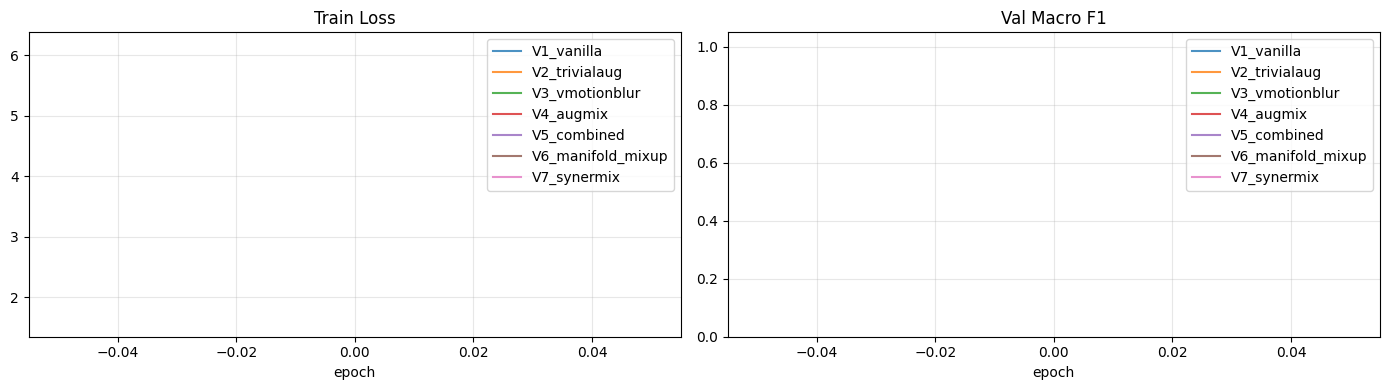

📈 saved: /Users/sangyub/Downloads/Smart-Factory_AI_Challenge/smart-factory_obisian/implementation/experiments/aug-ablation-2026-05-06/curves.png


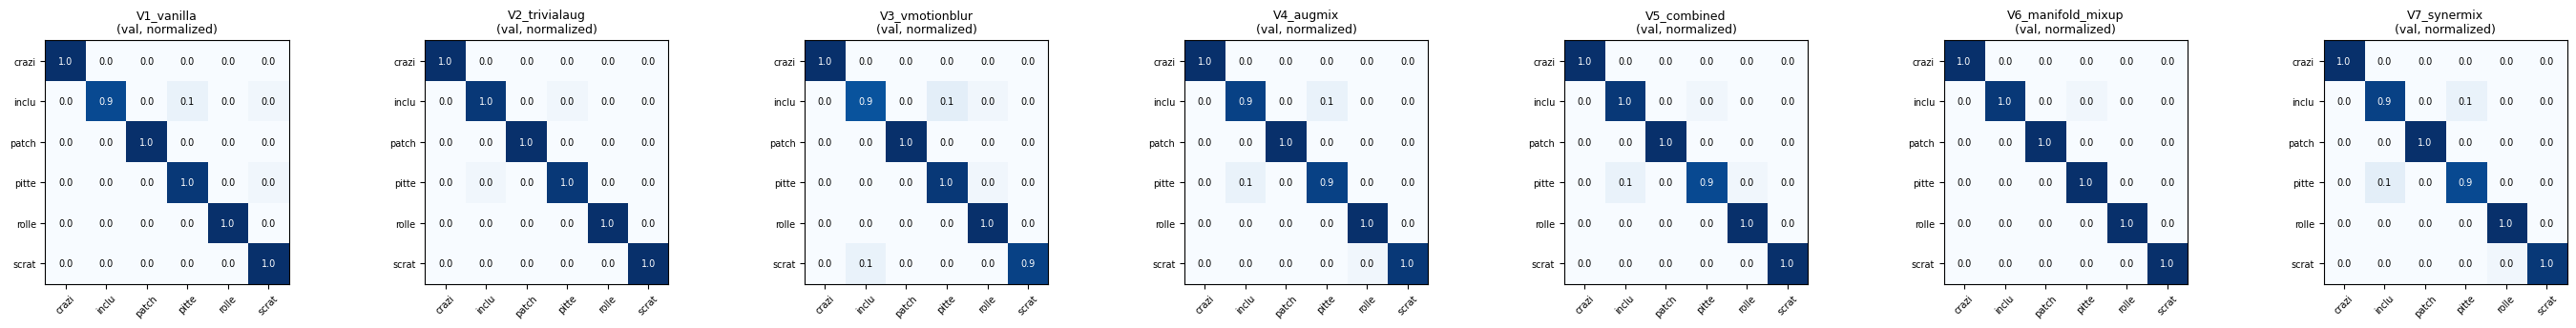

📈 saved: /Users/sangyub/Downloads/Smart-Factory_AI_Challenge/smart-factory_obisian/implementation/experiments/aug-ablation-2026-05-06/confusion_matrices.png


In [29]:
# === Loss curves + Val F1 curves ===
import json as _json
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for v in cfg.VARIANTS:
    hist_path = os.path.join(cfg.OUT_DIR, f'history_{v}.json')
    if not os.path.exists(hist_path): continue
    h = _json.load(open(hist_path))
    axes[0].plot(h['train_loss'], label=v, alpha=0.8)
    axes[1].plot(h['val_f1'], label=v, alpha=0.8)
axes[0].set_title('Train Loss'); axes[0].set_xlabel('epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].set_title('Val Macro F1'); axes[1].set_xlabel('epoch'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig(os.path.join(cfg.OUT_DIR, 'curves.png'), dpi=100, bbox_inches='tight')
plt.show()
print(f'📈 saved: {cfg.OUT_DIR}/curves.png')

# === Confusion matrices (val) ===
n_v = len(cfg.VARIANTS)
fig, axes = plt.subplots(1, n_v, figsize=(4*n_v, 3.5))
if n_v == 1: axes = [axes]
for ax, v in zip(axes, cfg.VARIANTS):
    cm, _ = all_confusion[v]
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1e-9)
    im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
    ax.set_title(f'{v}\n(val, normalized)', fontsize=9)
    ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels([c[:5] for c in CLASSES], rotation=45, fontsize=7)
    ax.set_yticklabels([c[:5] for c in CLASSES], fontsize=7)
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, f'{cm_norm[i,j]:.1f}', ha='center', va='center',
                    color='white' if cm_norm[i,j] > 0.5 else 'black', fontsize=7)
plt.tight_layout()
plt.savefig(os.path.join(cfg.OUT_DIR, 'confusion_matrices.png'), dpi=100, bbox_inches='tight')
plt.show()
print(f'📈 saved: {cfg.OUT_DIR}/confusion_matrices.png')


## 🔍 자동 분석 — Pattern matching + Anomaly detection + 추천

In [33]:
# === Auto analysis ===
def analyze_results(df, all_per_class_val):
    print('=' * 70)
    print('🔍 AUTO ANALYSIS')
    print('=' * 70)

    v1_f1 = df[df['Variant']=='V1_vanilla']['Val MacroF1'].values[0]
    deltas = {row['Variant']: row['Val MacroF1'] - v1_f1 for _, row in df.iterrows()}

    print(f'\n[1] Δ vs V1 vanilla (Val F1):')
    for v, d in deltas.items():
        marker = ' 🥇' if d == max(deltas.values()) and d > 0 else ''
        print(f'  {v:18s}: {d:+.4f}{marker}')

    # Pattern matching
    max_v = max(deltas, key=deltas.get)
    max_d = deltas[max_v]
    v3_d = deltas.get('V3_vmotionblur', 0)
    v5_d = deltas.get('V5_combined', 0)

    print(f'\n[2] Pattern matching:')
    if max_d < 0.005:
        case = 'D — 모두 평탄'
        diag = '모든 variant V1 대비 미미 (<0.5%). backbone(MobileNetV4-Conv-Small) 변별력 부족 가능성.'
        recs = ['→ Backbone swap 우선 (TinyViT-5M, GhostNetV3 1.0×)',
                '→ aug ablation은 더 강한 backbone에서 재실행',
                '→ 또는 Val이 너무 쉬워 (clean) — Kaggle motion-blur 제출에서 진짜 차이 보일 수도']
    elif max_v == 'V5_combined' and v5_d > v3_d:
        case = 'A — Stack winner'
        diag = f'V5 combined가 single 변형보다 우수. L1+L2+L3 시너지 확인.'
        recs = ['→ V5 채택 후 backbone swap',
                '→ L4 (SynerMix) 추가 검토 (v2 ablation)',
                '→ INT8 quantization round 진행']
    elif max_v == 'V3_vmotionblur':
        case = 'B — V3 (MotionBlur) 단독 winner'
        diag = f'Vertical motion blur가 도메인 특화로 압도적 효과 ({v3_d:+.4f}).'
        recs = ['→ kernel size [3,31] uniform → bimodal 분포 시도',
                '→ p=0.7 → 0.85 강도 ↑',
                '→ V3 baseline 위에서 backbone swap']
    elif v5_d < v3_d - 0.005:
        case = 'C — Aug 간섭 (V5 < V3)'
        diag = 'Combined가 single보다 나쁨 — aug 충돌. JS λ 너무 크거나 TrivialAugment가 motion blur 효과 희석.'
        recs = ['→ AugMix λ 12 → 6 약화',
                '→ TrivialAugment 빼고 V3 단독 사용',
                '→ V3 + V4 (motion blur + AugMix) subset만 시도']
    else:
        case = f'Mixed — {max_v} winner'
        diag = f'{max_v}가 단독 winner ({max_d:+.4f}), V5가 이를 못 따라감.'
        recs = [f'→ {max_v} 채택 후 추가 ablation',
                '→ V5 구성에서 어느 부분이 방해되는지 분리 ablation']

    print(f'  Case: {case}')
    print(f'  진단: {diag}')
    print(f'  추천:')
    for r in recs: print(f'    {r}')

    # Anomaly detection
    print(f'\n[3] Anomaly detection:')
    anomalies = []
    if deltas.get('V4_augmix', 0) < -0.005:
        anomalies.append(f'⚠️  V4 (AugMix) < V1: JS loss λ=12 너무 강함. 6~10으로 낮추기 검토.')
    if abs(v3_d) < 0.01:
        anomalies.append(f'⚠️  V3 (MotionBlur) Δ ≈ 0: blur 강도 부족 또는 val이 이미 clean에 saturated.')
    # Per-class anomaly
    for v in cfg.VARIANTS:
        pc = all_per_class_val[v]
        for k, c in enumerate(CLASSES):
            if pc[k] < 0.5:
                anomalies.append(f'⚠️  {v}의 {c} 클래스 F1={pc[k]:.3f} (절반 이하) — 학습 실패 또는 aug가 이 클래스 결함 지움.')
    if not anomalies:
        print('  ✅ 명시적 anomaly 없음')
    else:
        for a in anomalies: print(f'  {a}')

    # Latency check
    print(f'\n[4] Latency check (새 룰: 1s 무감점, 30s 실격):')
    for _, row in df.iterrows():
        t = row['T_inf (s)']
        if t > 30:
            status = '🔴 실격'
        elif t > 1:
            status = f'🟡 {(t-1)*2.5:.2f}점 페널티'
        else:
            status = '✅ 무감점'
        print(f'  {row["Variant"]:18s}: T_inf={t:.2f}s → {status}')

    # Best variant 추천
    print(f'\n[5] 🏆 Best variant 추천:')
    best_idx = df['🏆 Score (val proxy)'].idxmax()
    best = df.iloc[best_idx]
    print(f'  → {best["Variant"]} (val F1={best["Val MacroF1"]:.4f}, T_inf={best["T_inf (s)"]:.2f}s, score proxy={best["🏆 Score (val proxy)"]:.2f})')
    print(f'\n  ⚠️  단 val proxy는 clean F1 기반. Kaggle 제출해서 motion-blur F1 받은 후 최종 결정.')

analyze_results(df, all_per_class_val)


🔍 AUTO ANALYSIS

[1] Δ vs V1 vanilla (Val F1):
  V1_vanilla        : +0.0000
  V2_trivialaug     : +0.0112
  V3_vmotionblur    : -0.0168
  V4_augmix         : -0.0055
  V5_combined       : -0.0001
  V6_manifold_mixup : +0.0167 🥇
  V7_synermix       : -0.0110

[2] Pattern matching:
  Case: Mixed — V6_manifold_mixup winner
  진단: V6_manifold_mixup가 단독 winner (+0.0167), V5가 이를 못 따라감.
  추천:
    → V6_manifold_mixup 채택 후 추가 ablation
    → V5 구성에서 어느 부분이 방해되는지 분리 ablation

[3] Anomaly detection:
  ⚠️  V4 (AugMix) < V1: JS loss λ=12 너무 강함. 6~10으로 낮추기 검토.

[4] Latency check (새 룰: 1s 무감점, 30s 실격):
  V1_vanilla        : T_inf=4.73s → 🟡 9.33점 페널티
  V2_trivialaug     : T_inf=4.79s → 🟡 9.47점 페널티
  V3_vmotionblur    : T_inf=4.79s → 🟡 9.47점 페널티
  V4_augmix         : T_inf=4.94s → 🟡 9.85점 페널티
  V5_combined       : T_inf=3.69s → 🟡 6.72점 페널티
  V6_manifold_mixup : T_inf=3.53s → 🟡 6.32점 페널티
  V7_synermix       : T_inf=3.56s → 🟡 6.40점 페널티

[5] 🏆 Best variant 추천:
  → V6_manifold_mixup (val F1=0.9944, T_inf=3.

## 🏆 Best variant — 최종 submission.csv 생성 (Kaggle 제출용)

val F1 기준 best variant 자동 선정 → checkpoint 로드 → CPU 강제 추론 → submission.csv 저장.

In [34]:
# === Best variant final submission (leaderboard 기반 누적 best) ===
# 모든 누적 run 중 score_val_proxy 가 가장 높은 run을 자동 선정 → 그 run 의 ckpt 로드 → 최종 submission.csv

def load_best_model(by='score', alias=None, verbose=True):
    """leaderboard.json 에서 누적 best run 의 model 로드.

    Args:
        by: 'score' (=score_val_proxy) | 'val_f1'
        alias: model_alias 필터. None 이면 현재 cfg 의 MODEL_ALIAS 사용. 'all' 이면 전체.
        verbose: 선정 과정 출력
    Returns:
        (model, best_run_meta) — model은 CPU eval 모드
    """
    lb = load_leaderboard()
    if not lb['runs']:
        raise FileNotFoundError(
            f'leaderboard 비어있음 ({LEADERBOARD_PATH}) — Run all variants 셀 먼저 실행'
        )
    a = None if alias == 'all' else (alias if alias is not None else MODEL_ALIAS)
    best = get_overall_best_run(by=by, lb=lb, alias=a)
    if best is None:
        raise FileNotFoundError(f'leaderboard 에 alias={a!r} 인 run 없음')
    ckpt_full = os.path.join(cfg.OUT_DIR, best['ckpt_path']) if best.get('ckpt_path') else None
    if ckpt_full is None or not os.path.exists(ckpt_full):
        # fallback: variant best 호환 파일 (model_{alias}__{variant}.pth)
        fa = best.get('model_alias', MODEL_ALIAS)
        fallback = os.path.join(cfg.OUT_DIR, f"model_{fa}__{best['variant']}.pth")
        if not os.path.exists(fallback):
            raise FileNotFoundError(f'ckpt 없음: {ckpt_full} (fallback={fallback})')
        ckpt_full = fallback
        if verbose:
            print(f'⚠️  run-specific ckpt 없음 → fallback {os.path.basename(ckpt_full)}')

    if verbose:
        print(f'📂 Loading best run: alias={best.get("model_alias","?")}  variant={best["variant"]}  run_id={best["run_id"]}')
        print(f'   path: {ckpt_full}')
        print(f'   val_f1={best["val_f1"]:.4f}  t_inf={best["t_inf_sec"]:.2f}s  score={best.get("score_val_proxy",0):.2f}')

    ckpt = torch.load(ckpt_full, map_location='cpu', weights_only=False)
    model = make_model().cpu()
    model.load_state_dict(ckpt['state_dict'])
    model.eval()
    return model, best

# === Leaderboard top-10 출력 ===
_lb = load_leaderboard()
print('=' * 80)
print(f'📊 LEADERBOARD ({len(_lb["runs"])} runs 누적) — score_val_proxy top 10')
print('=' * 80)
_top = sorted(_lb['runs'], key=lambda r: r.get('score_val_proxy', -1), reverse=True)[:10]
print(f'{"#":>2} {"alias":>8} {"run_id":17} {"variant":22} {"val_f1":>7} {"t_inf":>6} {"score":>7}')
for i, r in enumerate(_top, 1):
    star = ' ⭐' if i == 1 else ''
    print(f'{i:>2} {r.get("model_alias","?"):>8} {r["run_id"]:17} {r["variant"]:22} {r["val_f1"]:>7.4f} {r["t_inf_sec"]:>6.2f} {r.get("score_val_proxy",0):>7.2f}{star}')

# === Best 모델 로드 + 최종 submission.csv ===
print('\n' + '=' * 80)
print('🏆 Loading overall best model (across all accumulated runs)')
print('=' * 80)
model, best_meta = load_best_model(by='score')

predictions, image_ids = [], []
print('\n🚀 추론 시작 (CPU 강제, 대회 환경 모사)...')
start_time = time.time()
with torch.no_grad():
    for images, img_names in real_loader:
        images = images.cpu()
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        predictions.extend(preds.cpu().numpy().tolist())
        image_ids.extend(list(img_names))
total_inference_time = time.time() - start_time
print(f'✅ 추론 완료. 총 소요: {total_inference_time:.2f}초')

# Submission CSV — 모든 row 에 inference_time_sec broadcast
submission_df = pd.DataFrame({
    'Id': image_ids,
    'Expected': predictions,
    'inference_time_sec': round(total_inference_time, 2),
})
submission_path = os.path.join(cfg.OUT_DIR, 'submission.csv')
submission_df.to_csv(submission_path, index=False)

val_f1 = best_meta['val_f1']
score, note = compute_competition_score(val_f1, total_inference_time)

print(f'\n🎉 Final submission: {submission_path}')
print(f'   variant: {best_meta["variant"]}  (run_id={best_meta["run_id"]}, best_epoch={best_meta.get("best_epoch")})')
print(f'   ckpt: {best_meta.get("ckpt_path")}')
print(f'   🏆 Estimated score (val proxy): {score:.2f} ({note})')
print(f'   ⚠️  진짜 점수는 Kaggle 제출 후 확인.')
print(submission_df.head())


📊 LEADERBOARD (33 runs 누적) — score_val_proxy top 10
 #    alias run_id            variant                 val_f1  t_inf   score
 1   mbv4cs 20260507_154937   V6_manifold_mixup       0.9944   3.53   93.12 ⭐
 2   mbv4cs 20260507_154937   V5_combined             0.9776   3.69   91.03
 3   mbv4cs 20260507_154937   V7_synermix             0.9667   3.56   90.28
 4   mbv4cs 20260507_154937   V2_trivialaug           0.9889   4.79   89.42
 5   mbv4cs 20260507_154937   V1_vanilla              0.9777   4.73   88.45
 6   mbv4cs 20260507_154937   V4_augmix               0.9722   4.94   87.37
 7   mbv4cs 20260507_154937   V3_vmotionblur          0.9609   4.79   86.60
 8   mbv4cs 20260507_152142   V1_vanilla              0.7387   4.78   64.42
 9   mbv4cs 20260507_153205   V1_vanilla              0.7387   4.83   64.29
10   mbv4cs 20260507_154912   V1_vanilla              0.7387   4.86   64.21

🏆 Loading overall best model (across all accumulated runs)
📂 Loading best run: alias=mbv4cs  variant=V6_manif

---

## 해석 가이드 (실측 후)

결과 표를 보고 다음 패턴 확인:

1. **V3 (Vertical MotionBlur) Δ vs V1 가장 큼**
   → 도메인 특화 aug가 가장 큰 단일 기여. round 2 (KD)·3 (Backbone) 시 V3 baseline 위에서 시작.

2. **V5 Combined < (V2 + V3 + V4 합)**
   → aug 간 conflict 또는 학습 capacity 부족. 개별 강도 (p=0.7 → 0.5) 재조정 필요.

3. **모든 variant이 V1 대비 미미 (< 1%)**
   → 모델 너무 작거나 epoch 부족. EPOCHS=50 또는 backbone upgrade 검토.

4. **Val F1는 좋지만 실제 Kaggle 점수가 떨어짐**
   → val(clean) ↔ test(blur) 갭이 다른 차원에 있음. CCMBA-style class-aware aug, 또는 KD round 가속.

## 다음 단계 제안

- 결과 → `wiki/finding-aug-component-ablation-<DATE>.md` 작성
- Manifold Mixup / SynerMix 추가 ablation (`paper-manifold-mixup-2019`, `paper-synermix-2024`) — forward override 필요
- Round 2: Knowledge Distillation 리서치 (heavy teacher with full aug stack → small student)

## 🗜️ INT8 PTQ Quantization (CPU 가속)

PyTorch FX graph mode static PTQ로 best variant fp32 → INT8 변환.
Calibration: train data 200 samples. CPU 강제 추론으로 latency 측정.
대회 공식 점수로 fp32 vs INT8 비교 → submission_int8.csv 생성.

→ 분석: [[concept-int8-ptq]], [[output/insights/quantization-strategy-20260507]]

In [ ]:
# === INT8 PTQ (FX graph mode static, auto backend) ===
import torch
import torch.nn as nn
import platform
from torch.ao.quantization import get_default_qconfig, QConfigMapping
from torch.ao.quantization.quantize_fx import prepare_fx, convert_fx

# Quantization backend auto-detect
#   - Apple Silicon (arm64) macOS: 'qnnpack' 만 작동 (x86/fbgemm prepack 커널 미등록)
#   - Kaggle/Colab CPU (x86 Linux): 'x86' / 'fbgemm' 작동
#   - PyTorch 의 supported_engines 가 권위 있는 list
_supported = list(torch.backends.quantized.supported_engines)
_machine = platform.machine().lower()
if _machine in ('arm64', 'aarch64') and 'qnnpack' in _supported:
    _qbackend = 'qnnpack'
elif 'x86' in _supported:
    _qbackend = 'x86'
elif 'fbgemm' in _supported:
    _qbackend = 'fbgemm'
elif 'qnnpack' in _supported:
    _qbackend = 'qnnpack'
else:
    raise RuntimeError(f'No quantization backend available: {_supported}')
torch.backends.quantized.engine = _qbackend
print(f'🔧 Quantization backend: {_qbackend}  (machine={_machine}, supported={_supported})')

# fp32 best 자동 로드 (leaderboard score 기준 — INT8 entry 가 이미 있으면 그걸 피하고 fp32 만 골라야 함)
_lb = load_leaderboard()
_fp32_runs = [r for r in _lb['runs']
              if not r['variant'].endswith('_INT8')
              and r.get('model_alias') == MODEL_ALIAS]
if not _fp32_runs:
    raise FileNotFoundError(f'leaderboard 에 alias={MODEL_ALIAS!r} fp32 run 없음 — Run all variants 셀 먼저 실행')
fp32_meta = max(_fp32_runs, key=lambda r: r.get('score_val_proxy', -1))
fp32_ckpt_full = os.path.join(cfg.OUT_DIR, fp32_meta['ckpt_path'])
fp32_ckpt = torch.load(fp32_ckpt_full, map_location='cpu', weights_only=False)
fp32_model = make_model().cpu()
fp32_model.load_state_dict(fp32_ckpt['state_dict'])
fp32_model.eval()

val_f1_fp32 = fp32_meta['val_f1']
total_inference_time_fp32 = fp32_meta['t_inf_sec']
source_variant = fp32_meta['variant']
source_run_id = fp32_meta['run_id']
print(f'📂 fp32 source (leaderboard score best):')
print(f'   variant={source_variant}  run_id={source_run_id}')
print(f'   val_f1={val_f1_fp32:.4f}  t_inf={total_inference_time_fp32:.2f}s  score={fp32_meta.get("score_val_proxy",0):.2f}')

# Quantization config (backend matches engine — qconfig backend 와 engine 불일치 시 또 NoQEngine)
qconfig = get_default_qconfig(_qbackend)
qconfig_mapping = QConfigMapping().set_global(qconfig)
example_input = (torch.randn(1, 3, cfg.INPUT_SIZE, cfg.INPUT_SIZE),)

print('\n🔬 Preparing model for PTQ (FX graph mode)...')
try:
    prepared_model = prepare_fx(fp32_model, qconfig_mapping, example_input)
    print('   ✅ FX graph trace 성공')
except Exception as e:
    print(f'   ❌ FX trace 실패: {e}')
    print('   → Fallback 필요 (ONNX export + ORT quant)')
    raise

# Calibrate with train data (200 samples — clean, labeled, 6 classes)
print('\n🔬 Calibrating (train data 200 samples)...')
calib_dataset = ImageFolder(TRAIN_DIR, transform=EVAL_TF)
calib_loader = DataLoader(calib_dataset, batch_size=32, shuffle=False, num_workers=0)
prepared_model.eval()
n_calib = 0
with torch.no_grad():
    for x, _ in calib_loader:
        prepared_model(x.cpu())
        n_calib += x.size(0)
        if n_calib >= 200:
            break
print(f'   ✅ Calibration done ({n_calib} samples)')

# Convert to INT8 (engine 이 set 되어 있어야 prepack 커널 dispatch 됨)
print('\n🗜️ Converting fp32 → INT8...')
assert torch.backends.quantized.engine == _qbackend, f'engine mismatch: {torch.backends.quantized.engine} != {_qbackend}'
int8_model = convert_fx(prepared_model)
int8_model.eval()
print('   ✅ INT8 model ready')

# 누적 저장 (runs/<variant>_INT8/<RUN_ID>__from_<source_run_id>.pth)
int8_variant_name = f'{source_variant}_INT8'
int8_run_dir = os.path.join(RUNS_DIR, int8_variant_name)
os.makedirs(int8_run_dir, exist_ok=True)
int8_fname_base = f'{MODEL_ALIAS}__{int8_variant_name}__{RUN_ID}__from_{source_run_id}'
int8_run_pth = os.path.join(int8_run_dir, f'{int8_fname_base}.pth')
int8_payload = {
    'variant': int8_variant_name,
    'source_variant': source_variant,
    'source_run_id': source_run_id,
    'run_id': RUN_ID,
    'model_name': cfg.MODEL_NAME,
    'model_alias': MODEL_ALIAS,
    'fp32_val_f1': val_f1_fp32,
    'int8_state_dict': int8_model.state_dict(),
    'quantization': f'fx_static_{_qbackend}',
    'calibration_samples': n_calib,
    'config': {k: v for k, v in cfg.__dict__.items() if not k.startswith('_')},
}
torch.save(int8_payload, int8_run_pth)
print(f'   💾 [accum] runs/{int8_variant_name}/{int8_fname_base}.pth')

# 호환 카피 — model_<alias>__<variant>_int8.pth (덮어씀; 매 round 새 INT8 가 우선)
int8_compat_pth = os.path.join(cfg.OUT_DIR, f'model_{MODEL_ALIAS}__{source_variant}_int8.pth')
torch.save(int8_payload, int8_compat_pth)
print(f'   💾 [compat] {os.path.basename(int8_compat_pth)}')


In [ ]:
# === INT8 evaluation + submission + leaderboard append + 최종 submission.csv 자동 갱신 ===
@torch.no_grad()
def eval_cpu_macro_f1(model, loader):
    model.eval()
    ys, ps = [], []
    for x, y in loader:
        x = x.cpu()
        out = model(x).argmax(-1).cpu().numpy()
        ys.append(y.numpy()); ps.append(out)
    return f1_score(np.concatenate(ys), np.concatenate(ps), average='macro')

# Val F1 — INT8 (clean 180)
print('🎯 INT8 evaluation on val 180 (clean, labeled)...')
val_f1_int8 = eval_cpu_macro_f1(int8_model, val_loader)
delta_acc = val_f1_int8 - val_f1_fp32
print(f'   Val F1 fp32: {val_f1_fp32:.4f}')
print(f'   Val F1 INT8: {val_f1_int8:.4f}  (Δ = {delta_acc:+.4f})')
if abs(delta_acc) > 0.02:
    print(f'   ⚠️  acc drop {abs(delta_acc)*100:.1f}%p — AdaRound 검토 필요')
elif abs(delta_acc) < 0.005:
    print(f'   ✅ acc drop 거의 없음 — INT8 안전')

# Real test inference + latency (INT8, CPU)
print('\n🚀 INT8 inference on real test (CPU 강제, 대회 환경 모사)...')
predictions_int8, image_ids_int8 = [], []
start_time = time.time()
with torch.no_grad():
    for images, img_names in real_loader:
        images = images.cpu()
        outputs = int8_model(images)
        _, preds = torch.max(outputs, 1)
        predictions_int8.extend(preds.cpu().numpy().tolist())
        image_ids_int8.extend(list(img_names))
total_inference_time_int8 = time.time() - start_time
speedup = total_inference_time_fp32 / total_inference_time_int8 if total_inference_time_int8 > 0 else 1.0
print(f'   ✅ INT8 추론: {total_inference_time_int8:.2f}s  ({speedup:.2f}× speedup vs fp32 {total_inference_time_fp32:.2f}s)')

# Pred dist
pred_dist_int8 = {IDX_TO_CLASS[k]: 0 for k in range(NUM_CLASSES)}
for p in predictions_int8:
    pred_dist_int8[IDX_TO_CLASS[p]] += 1
print(f'   real test 예측 분포 (INT8): {pred_dist_int8}')

# 누적 INT8 submission CSV (모든 row 에 inference_time_sec broadcast)
submission_int8_df = pd.DataFrame({
    'Id': image_ids_int8,
    'Expected': predictions_int8,
    'inference_time_sec': round(total_inference_time_int8, 2),
})
int8_run_csv = os.path.join(int8_run_dir, f'{int8_fname_base}.submission.csv')
submission_int8_df.to_csv(int8_run_csv, index=False)
print(f'   📝 [accum] runs/{int8_variant_name}/{int8_fname_base}.submission.csv')

# 호환 카피 — submission_<alias>_int8.csv (덮어씀)
submission_int8_compat = os.path.join(cfg.OUT_DIR, f'submission_{MODEL_ALIAS}_int8.csv')
submission_int8_df.to_csv(submission_int8_compat, index=False)

# Competition score 비교 (val F1 proxy)
score_fp32, note_fp32 = compute_competition_score(val_f1_fp32, total_inference_time_fp32)
score_int8, note_int8 = compute_competition_score(val_f1_int8, total_inference_time_int8)
delta_score = score_int8 - score_fp32

print(f'\n🏆 Competition score 비교 (val F1 proxy):')
print(f'  fp32: {score_fp32:.2f}  (val_f1={val_f1_fp32:.4f}, T={total_inference_time_fp32:.2f}s, {note_fp32})')
print(f'  INT8: {score_int8:.2f}  (val_f1={val_f1_int8:.4f}, T={total_inference_time_int8:.2f}s, {note_int8})')
print(f'  Δ score: {delta_score:+.2f}')

# Latency budget 통과 여부
if total_inference_time_int8 <= 1.0:
    print(f'  🎯 새 룰 1s 무감점 budget 통과 ✅')
elif total_inference_time_int8 <= 30.0:
    penalty = (total_inference_time_int8 - 1) * 2.5
    print(f'  🟡 1s 초과 — penalty {penalty:.2f}점 (실격 안 넘음)')
else:
    print(f'  🔴 30s 초과 — 실격')

# Leaderboard 에 INT8 entry append
int8_entry = {
    'run_id': RUN_ID,
    'variant': int8_variant_name,
    'timestamp': datetime.now().isoformat(timespec='seconds'),
    'model_name': cfg.MODEL_NAME + ' (INT8)',
    'model_alias': MODEL_ALIAS,
    'epochs_trained': fp32_meta.get('epochs_trained'),
    'best_epoch': fp32_meta.get('best_epoch'),
    'val_f1': float(round(val_f1_int8, 4)),
    'dummy_f1': None,
    't_inf_sec': float(round(total_inference_time_int8, 4)),
    'score_val_proxy': float(round(score_int8, 2)),
    'score_dummy_proxy': None,
    'is_new_variant_best': True,
    'prev_variant_best': None,
    'ckpt_path': os.path.relpath(int8_run_pth, cfg.OUT_DIR),
    'history_path': None,
    'submission_path': os.path.relpath(int8_run_csv, cfg.OUT_DIR),
    'val_per_class_f1': None,
    'dummy_per_class_f1': None,
    'pred_dist': pred_dist_int8,
    'source_run_id': source_run_id,
    'source_variant': source_variant,
    'quantization': 'fx_static_x86',
}
append_leaderboard_run(int8_entry)
print(f'\n📊 leaderboard 에 INT8 entry 추가됨 (run_id={RUN_ID}, variant={int8_variant_name})')

# 최종 submission.csv 자동 갱신 — score 기준 더 좋은 쪽으로 덮어씀
final_sub = os.path.join(cfg.OUT_DIR, 'submission.csv')
if score_int8 >= score_fp32:
    submission_int8_df.to_csv(final_sub, index=False)
    print(f'\n⭐ submission.csv ← INT8 (score {score_int8:.2f} ≥ fp32 {score_fp32:.2f})')
    print(f'💡 Kaggle 제출: submission.csv')
else:
    print(f'\n⏭ submission.csv 유지 fp32 (INT8 score {score_int8:.2f} < fp32 {score_fp32:.2f})')
    print(f'💡 acc drop 이 latency 이득보다 큼 — fp32 채택. AdaRound/QAT 검토 권장.')

print(f'\n🎉 INT8 submission (별도): {submission_int8_compat}')
print(submission_int8_df.head())
